## Info 

This is the code I used for the biplanarity study. As is the case with all the code in this analysis section, it is a little archaic and chaotic. 

The main function used is `run_biplanarity_analysis()`. It used to be part of the DimensionalReduction.py area but I moved it here based on the new data storage structure, some internal functions are still being pulled from dr tho.

This needs to be run for all the DR cases that one wants to look at (e.g. DR from 2.0 to 11.0). At each stage the values of each mode and ordering need to be manually collected (in the next cell) and then everything after that is based on the manual collection... At least it works :)

In [1]:
import numpy as np 
import random as ran 
import matplotlib.pyplot as plt 
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D

import re
import glob 
import os

import importlib
import DimensionalReduction as dr
importlib.reload(dr)

<module 'DimensionalReduction' from '/hepusers2/fuscomus/DRToM/Analysis/DimensionalReduction.py'>

In [2]:
# ==========================
# Get LHE events from Data
# ==========================
base_path = "/hepusers2/fuscomus/DRToM/Data"
energy_folder = "TeV13p0"    # Options: TeV13p0, TeV13p6
dimensionality_2D = "2D"
dimensionality_3D = "3D"
what_process = "2to4"        # Options: 2to2, 2to3, 2to4, 2to5

Start = 9.0                 # What is the start of the generation range (TeV)
End = 11.0                  # What is the end of the generation range (TeV)
Step = 0.1                  # What is the step size of the generation range (TeV)
DR_scale = 11.0             # Any DR value allowed (TeV)

# Construct LHE file lists split by DR_scale
def _slice_label(s, e):
    return f"{s:.1f}to{e:.1f}"

lhe_2D_files = []
lhe_3D_files = []

# For each slice (e.g. 9.0to9.1) gather matching .lhe files from 3D or 2D folders
for slice in np.arange(Start, End, Step):
    slice = round(slice, 10)  # Avoid floating point issues
    slice_end = round(slice + Step, 10)
    label = _slice_label(slice, slice_end)
    if slice < DR_scale:
        # slices below DR_scale belong to 3D
        pattern = os.path.join(base_path, energy_folder, dimensionality_3D, what_process, f"{label}_*.lhe")
        matches = sorted(glob.glob(pattern))
        if matches:
            lhe_3D_files.extend(matches)
    else:
        # slices >= DR_scale belong to 2D
        pattern = os.path.join(base_path, energy_folder, dimensionality_2D, what_process, f"{label}_*.lhe")
        matches = sorted(glob.glob(pattern))
        if matches:
            lhe_2D_files.extend(matches)

# Remove duplicates and sort
lhe_2D_files = sorted(set(lhe_2D_files))
lhe_3D_files = sorted(set(lhe_3D_files))
# print(lhe_2D_files)
# print(lhe_3D_files)

# Combined local bunch: 3D (below DR) then 2D (above DR)
local_lhe_files = lhe_3D_files + lhe_2D_files

print(f"Found {len(lhe_3D_files)} 3D LHE files and {len(lhe_2D_files)} 2D LHE files.")
print(f"Combined local bunch size: {len(local_lhe_files)} files.")

# For backward compatibility keep the tuple descriptors
lhe_2D_set = (base_path, energy_folder, dimensionality_2D, what_process)
lhe_3D_set = (base_path, energy_folder, dimensionality_3D, what_process)    


# ==========================
# Boost to get CoM data also
# ==========================
filenames = local_lhe_files
directories = sorted(set(os.path.dirname(f) for f in filenames))
print(f"Processing {len(filenames)} LHE files across {len(directories)} directories.")

# Storage for each directory and subprocess
data_dict = {}

for filename in filenames:
    directory = os.path.dirname(filename)
    if directory not in data_dict:
        data_dict[directory] = {}
    grouped_data = dr.read_lhe_grouped_by_lprup(filename)
    if not grouped_data:
        print(f"Warning: No event data found in {filename}")
        continue

    for lprup, info in grouped_data.items():
        events = info.get("events", [])
        xsec = info.get("cross_section", 0.0)

        if lprup not in data_dict[directory]:
            data_dict[directory][lprup] = {
                "four_mom_lab": [], "four_mom_CoM": [],
            }

        dd = data_dict[directory][lprup]
        four_mom_lab = []
        four_mom_CoM = []

        for event in events:
            particles = event.get("final_state", [])
            try:
                M_event, boosted = dr.boost_to_com(particles, debug=False)
            except ValueError as e:
                print(f"[ERROR] Boost to CoM failed for event in file {filename}, lprup {lprup}: {e}")
                continue  # Skip this event entirely

            # Store lab and CoM four-momenta per event
            four_mom_lab.append(particles)
            four_mom_CoM.append(boosted)

        # store four-momenta for this LPRUP
        dd["four_mom_lab"].extend(four_mom_lab)
        dd["four_mom_CoM"].extend(four_mom_CoM)

        # Initialize a master list for this directory if not already
        data_dict[directory].setdefault("all_four_mom_lab", []).extend(four_mom_lab)
        data_dict[directory].setdefault("all_four_mom_CoM", []).extend(four_mom_CoM)

Found 20 3D LHE files and 0 2D LHE files.
Combined local bunch size: 20 files.
Processing 20 LHE files across 1 directories.



===== Processing frame: Lab =====
Total events: 440
Plot saved as Plots/BipStudy/allmodes_pT_Lab_bip_single.png
Plot saved as Plots/BipStudy/allmodes_E_Lab_bip_single.png
Overlay plot saved as Plots/BipStudy/allmodes_pT_Lab_bip_overlay.png
Overlay plot saved as Plots/BipStudy/allmodes_E_Lab_bip_overlay.png

===== Processing frame: CoM =====
Total events: 440
Plot saved as Plots/BipStudy/allmodes_pT_CoM_bip_single.png
Plot saved as Plots/BipStudy/allmodes_E_CoM_bip_single.png
Overlay plot saved as Plots/BipStudy/allmodes_pT_CoM_bip_overlay.png
Overlay plot saved as Plots/BipStudy/allmodes_E_CoM_bip_overlay.png


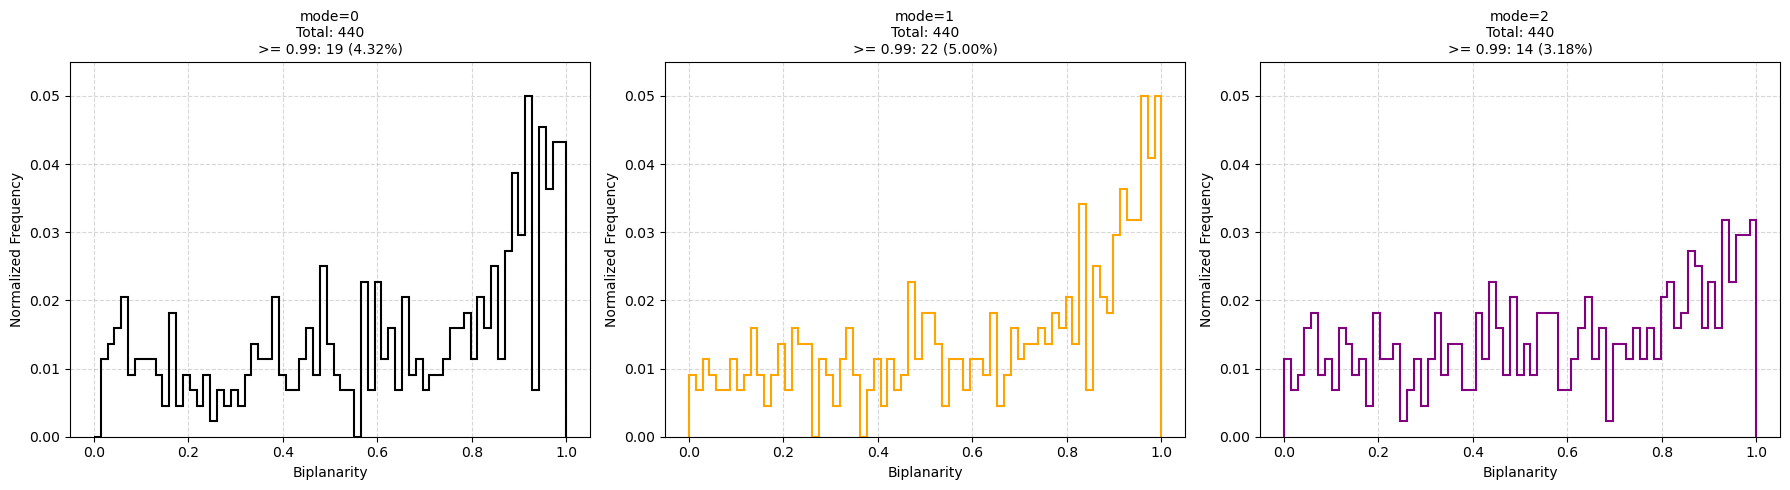

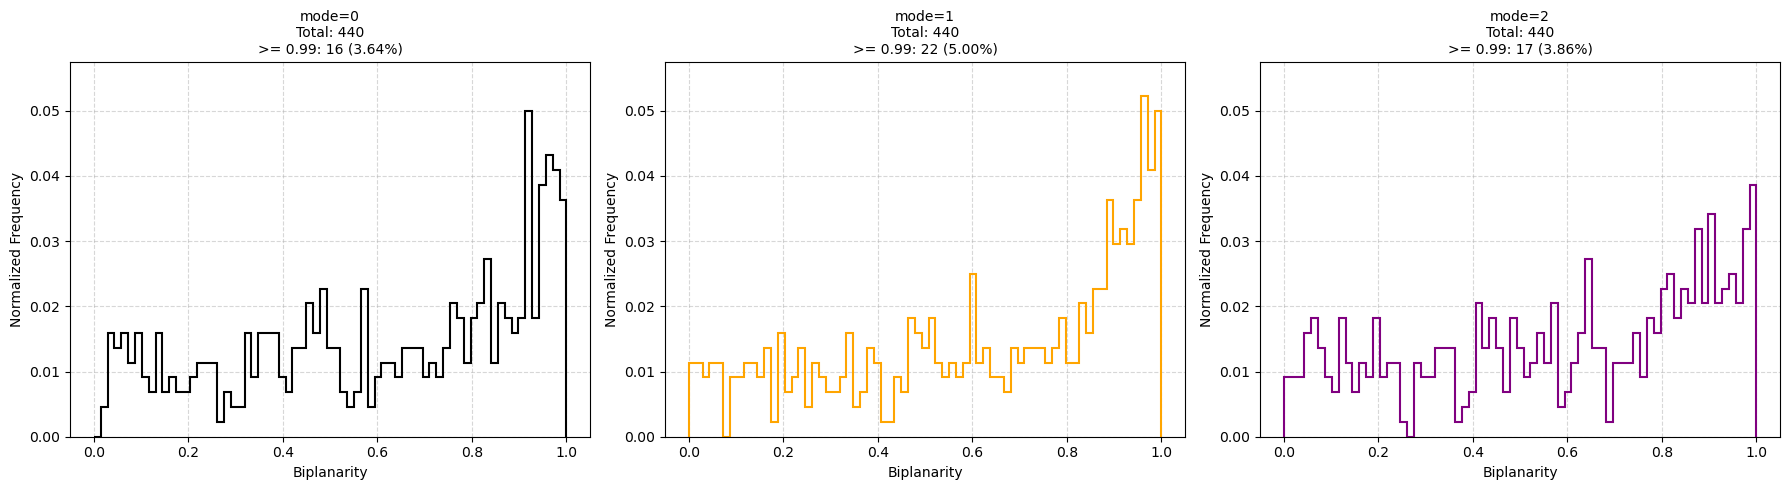

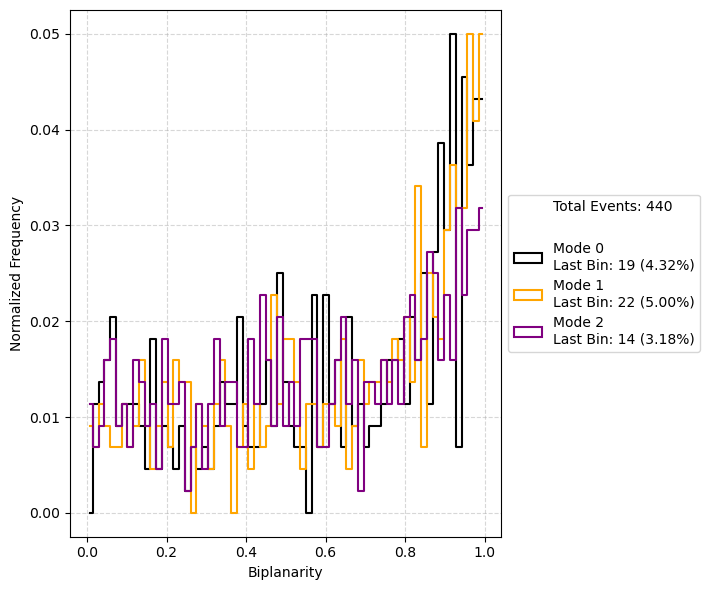

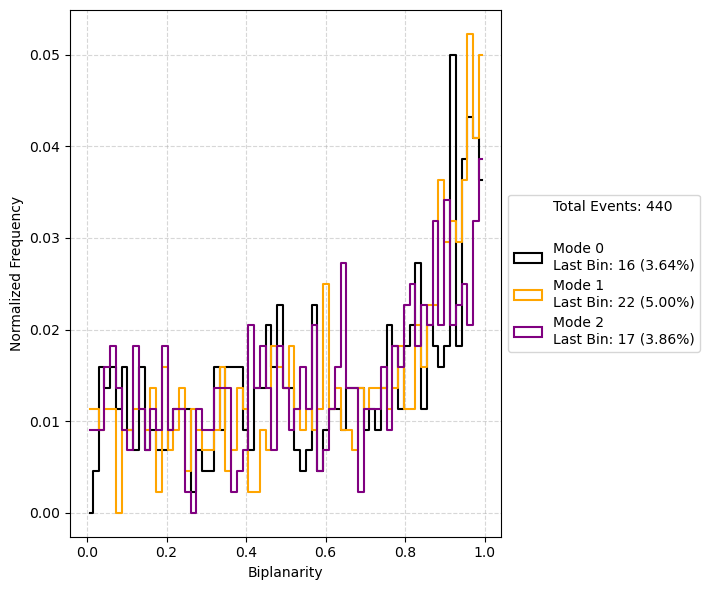

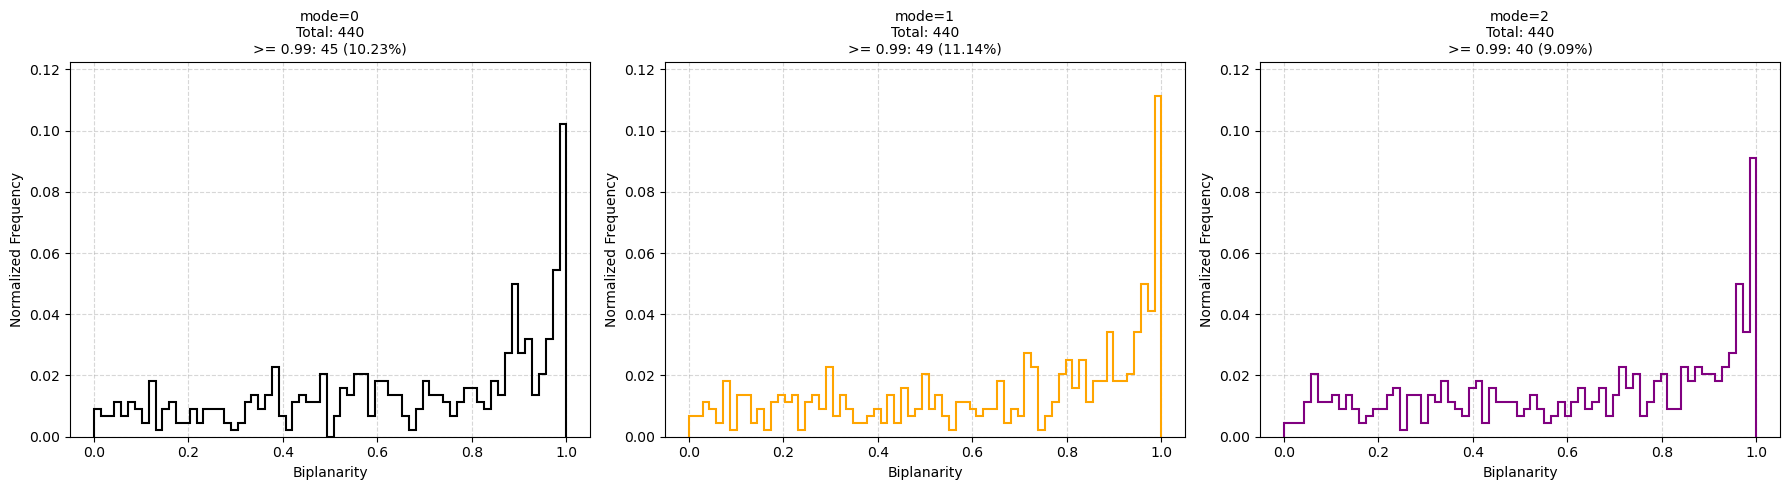

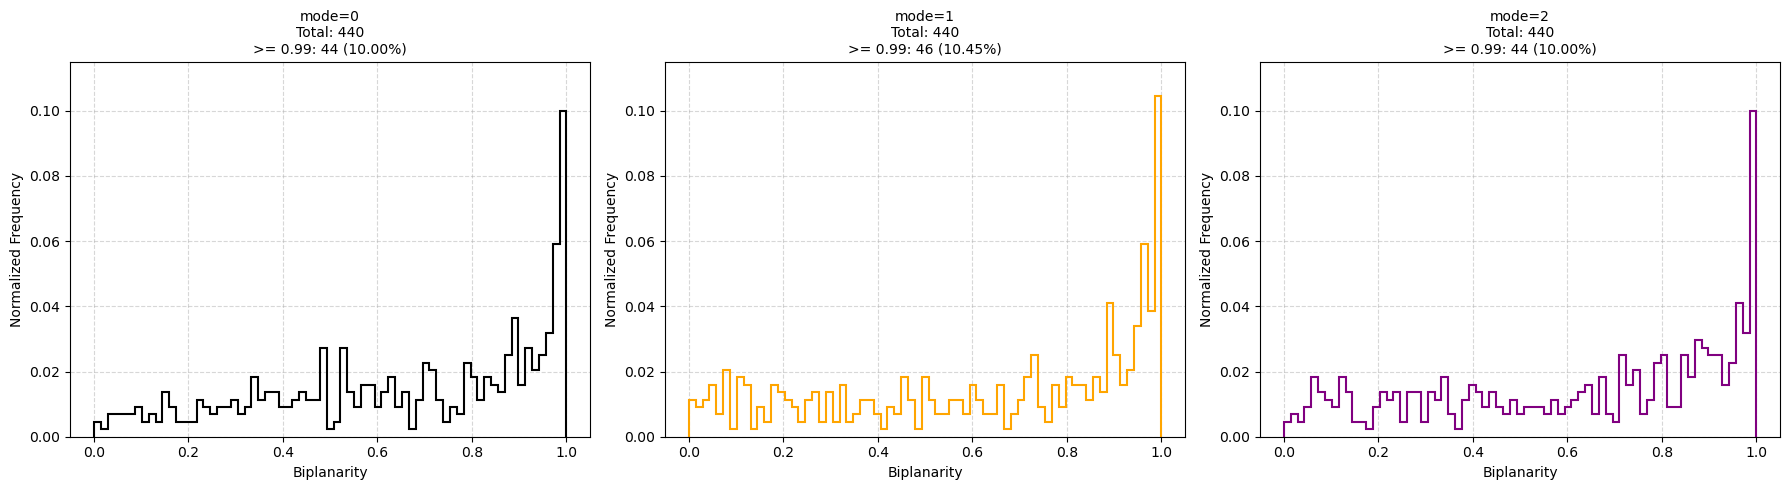

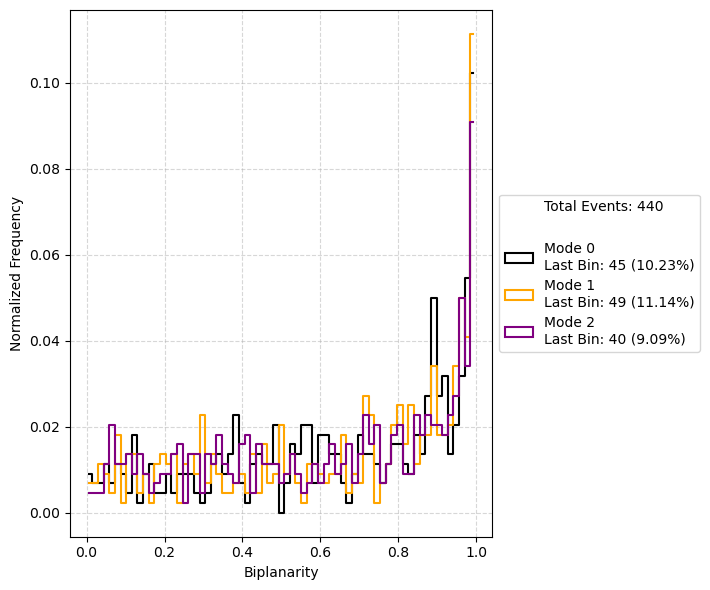

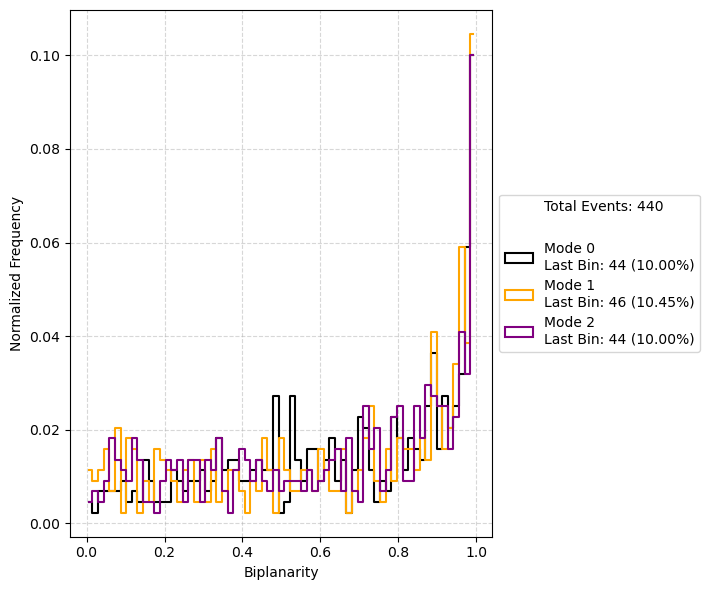

In [3]:
# ==========================
# Bip study
# ==========================

SORT_METHODS = ['pT', 'E']
BIPLANARITY_MODES = [0, 1, 2]

def compute_biplanarity_from_momenta(four_momenta, sort_by, mode):
    # four_momenta: list of events, each event = [(E, px, py, pz), ...]
    if not four_momenta:
        return []
    three_momenta, *_ = dr.diff_momentum(four_momenta)
    _, _, _, _, _, _, _, _, _, B = dr.calc_EventVars(
        four_momenta,
        three_momenta,
        sort_by=sort_by,
        mode=mode
    )
    B_vals = np.concatenate([np.array(vals).flatten() for vals in B])
    return B_vals

def run_biplanarity_analysis(data_dict, combine_by_frame=True):
    save_plots = True # The saving logic is in the plot functions which is silly
    print_latex = False

    def collect_events(frame_key):
        all_events = []
        for directory, lprup_dict in data_dict.items():
            for _, dd in lprup_dict.items():
                if not isinstance(dd, dict):
                    continue
                all_events.extend(dd.get(frame_key, []))
        return all_events

    for frame, key in [("Lab", "four_mom_lab"), ("CoM", "four_mom_CoM")]:
        print(f"\n===== Processing frame: {frame} =====")

        all_events = collect_events(key)

        if not all_events:
            print(f"No events found for {frame}")
            continue

        print(f"Total events: {len(all_events)}")

        B_data = {}

        for sort_by in SORT_METHODS:
            for mode in BIPLANARITY_MODES:
                B_vals = compute_biplanarity_from_momenta(all_events, sort_by, mode)
                B_data[(mode, sort_by)] = B_vals

        title_prefix = f"{energy_folder} {what_process} - {frame}"

        dr.plot_biplanarity_histograms(
            B_data,
            title_prefix,
            save_plots=save_plots,
            energy_label=title_prefix,
            frame=frame
        )

        dr.plot_biplanarity_overlay(
            B_data,
            title_prefix,
            save_plots=save_plots,
            energy_label=title_prefix,
            frame=frame
        )

        if print_latex:
            dr.generate_biplanarity_latex_table(
                B_data,
                table_caption=f"{frame} ordering",
                table_label=f"{frame}_ordering"
            )

run_biplanarity_analysis(data_dict, combine_by_frame=True)

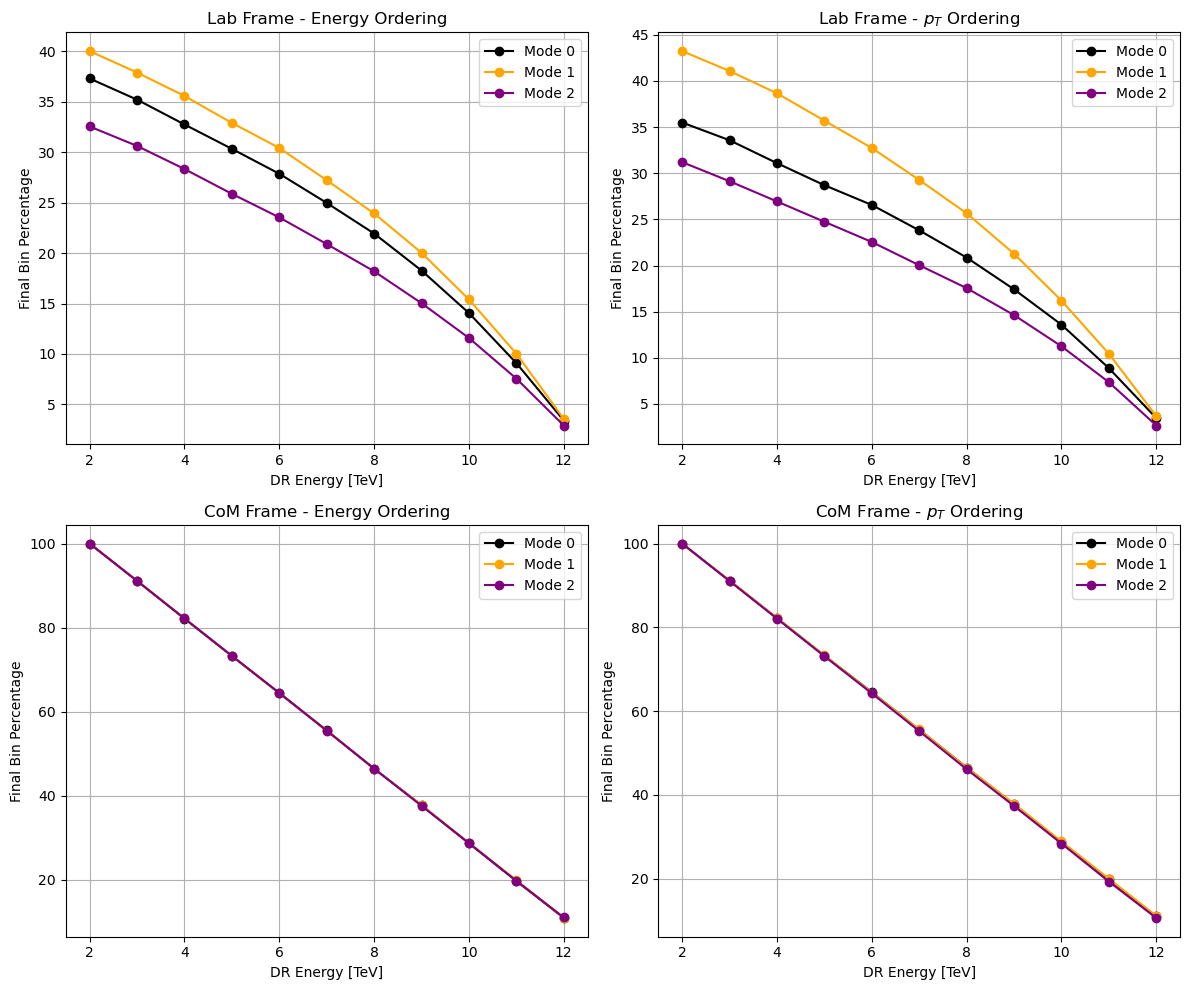

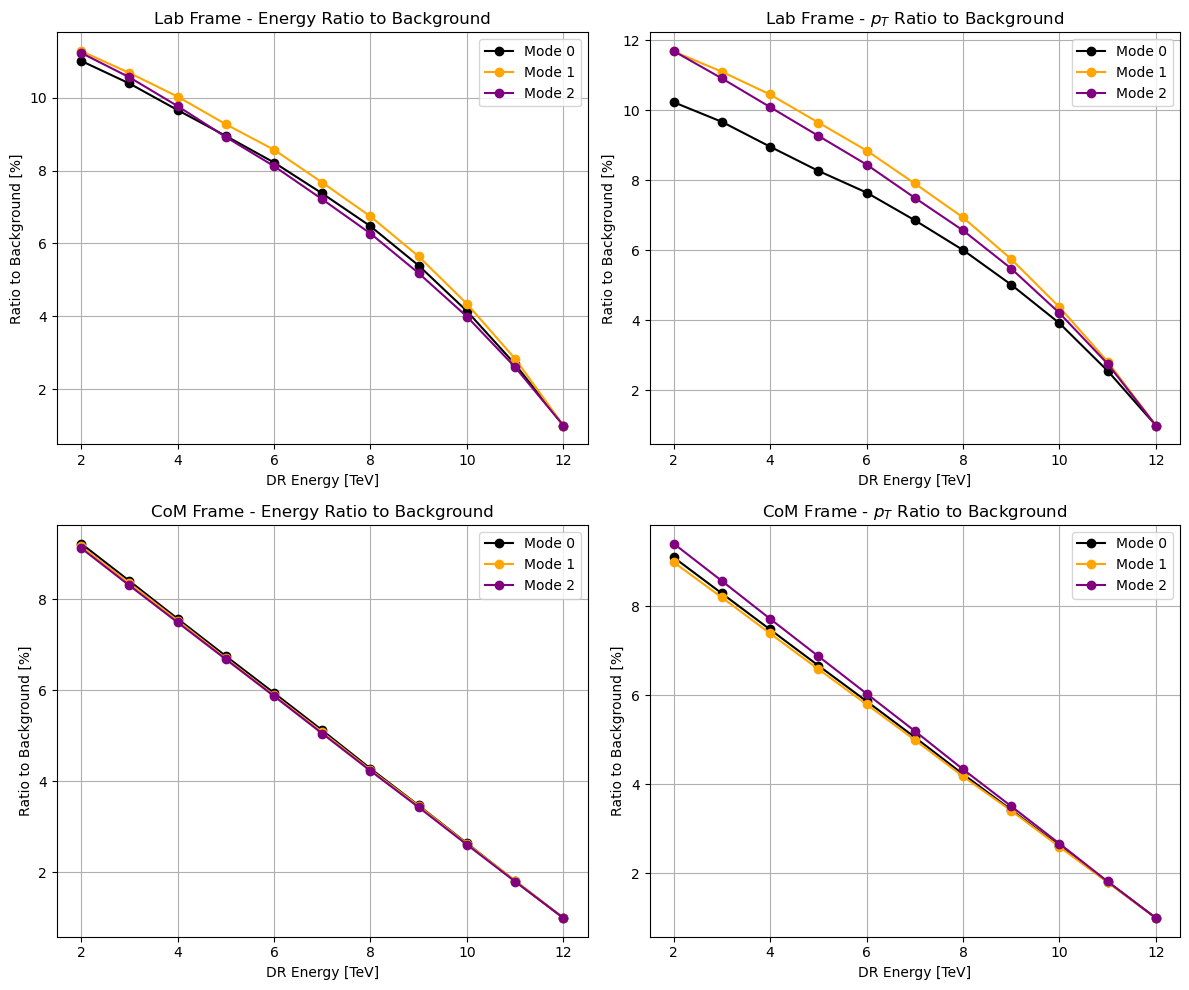


=== Ratio Values Grouped by Dataset and Mode ===

lab_E ratios:
  Mode 0: [11.01, 10.39, 9.66, 8.95, 8.22, 7.37, 6.47, 5.39, 4.14, 2.68, 1.00]
  Mode 1: [11.28, 10.68, 10.03, 9.27, 8.57, 7.67, 6.74, 5.64, 4.34, 2.83, 1.00]
  Mode 2: [11.23, 10.56, 9.77, 8.92, 8.12, 7.21, 6.27, 5.18, 3.99, 2.60, 1.00]

lab_pt ratios:
  Mode 0: [10.23, 9.67, 8.96, 8.27, 7.65, 6.86, 6.01, 5.02, 3.92, 2.56, 1.00]
  Mode 1: [11.68, 11.10, 10.45, 9.65, 8.85, 7.91, 6.94, 5.75, 4.38, 2.82, 1.00]
  Mode 2: [11.69, 10.91, 10.09, 9.27, 8.45, 7.50, 6.57, 5.48, 4.21, 2.76, 1.00]

com_E ratios:
  Mode 0: [9.22, 8.40, 7.57, 6.75, 5.94, 5.12, 4.28, 3.47, 2.64, 1.81, 1.00]
  Mode 1: [9.16, 8.35, 7.53, 6.70, 5.89, 5.08, 4.25, 3.46, 2.63, 1.82, 1.00]
  Mode 2: [9.12, 8.30, 7.49, 6.68, 5.87, 5.05, 4.23, 3.43, 2.61, 1.80, 1.00]

com_pt ratios:
  Mode 0: [9.10, 8.29, 7.48, 6.67, 5.87, 5.06, 4.23, 3.43, 2.62, 1.81, 1.00]
  Mode 1: [8.99, 8.20, 7.39, 6.59, 5.80, 5.00, 4.18, 3.41, 2.60, 1.80, 1.00]
  Mode 2: [9.41, 8.57, 7.72

In [4]:
# === Raw Data ===
# DR 2 to DR 12 
lab_E = [
    [37.32, 35.22, 32.76, 30.34, 27.87, 24.98, 21.94, 18.27, 14.05, 9.09, 3.39],
    [40.04, 37.91, 35.59, 32.91, 30.43, 27.23, 23.93, 20.03, 15.40, 10.03, 3.55],
    [32.56, 30.63, 28.34, 25.88, 23.54, 20.90, 18.19, 15.03, 11.58, 7.55, 2.90]
]

lab_pt = [
    [35.49, 33.57, 31.09, 28.70, 26.56, 23.81, 20.86, 17.42, 13.59, 8.88, 3.47],
    [43.23, 41.07, 38.66, 35.69, 32.73, 29.27, 25.66, 21.27, 16.20, 10.44, 3.70],
    [31.20, 29.13, 26.94, 24.74, 22.55, 20.03, 17.55, 14.63, 11.25, 7.36, 2.67]
]

com_E = [
    [100.00, 91.13, 82.13, 73.23, 64.43, 55.51, 46.41, 37.66, 28.63, 19.66, 10.85],
    [100.00, 91.13, 82.19, 73.21, 64.37, 55.49, 46.38, 37.77, 28.72, 19.83, 10.92],
    [100.00, 91.10, 82.17, 73.26, 64.41, 55.44, 46.40, 37.58, 28.67, 19.70, 10.97]
]

com_pt = [
    [100.00, 91.13, 82.20, 73.26, 64.52, 55.58, 46.54, 37.75, 28.74, 19.86, 10.99],
    [100.00, 91.17, 82.22, 73.32, 64.45, 55.63, 46.53, 37.90, 28.89, 20.00, 11.12],
    [100.00, 91.06, 82.08, 73.12, 64.24, 55.23, 46.13, 37.36, 28.40, 19.32, 10.63]
]

# === Plotting Setup ===
x = list(range(2, 13))  # DR2 to DR12 inclusive
modes = [0, 1, 2]
colors = ['black', 'orange', 'purple']

# Plot helper: Always show, only save if filename given
def plot_and_save(data, title, filename=None, ylabel='Final Bin Percentage'):
    plt.figure()
    for i, mode in enumerate(modes):
        plt.plot(x, data[i], label=f'Mode {mode}', color=colors[i], marker='o')
    plt.xlabel('DR Energy [TeV]')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300)
    plt.show()

# Ratio computation
def compute_ratios(data):
    return [[round(val / row[-1], 2) for val in row] for row in data]

# === Plot grouped raw data ===
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

datasets = [
    (lab_E, 'Lab Frame - Energy Ordering', 'lab_E_finalbin.png'),
    (lab_pt, 'Lab Frame - $p_T$ Ordering', 'lab_pt_finalbin.png'),
    (com_E, 'CoM Frame - Energy Ordering', 'com_E_finalbin.png'),
    (com_pt, 'CoM Frame - $p_T$ Ordering', 'com_pt_finalbin.png')
]

for ax, (data, title, filename) in zip(axs.flat, datasets):
    for i, mode in enumerate(modes):
        ax.plot(x, data[i], label=f'Mode {mode}', color=colors[i], marker='o')
    ax.set_xlabel('DR Energy [TeV]')
    ax.set_ylabel('Final Bin Percentage')
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    # Save each individually if filename provided
    plt.figure()
    for i, mode in enumerate(modes):
        plt.plot(x, data[i], label=f'Mode {mode}', color=colors[i], marker='o')
    plt.xlabel('DR Energy [TeV]')
    plt.ylabel('Final Bin Percentage')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    plt.close()

plt.tight_layout()
plt.show()

# === Compute ratios ===
ratios = {
    "lab_E": compute_ratios(lab_E),
    "lab_pt": compute_ratios(lab_pt),
    "com_E": compute_ratios(com_E),
    "com_pt": compute_ratios(com_pt),
}

# === Plot grouped ratio data ===
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

datasets = [
    (ratios["lab_E"], 'Lab Frame - Energy Ratio to Background', 'lab_E_ratio.png'),
    (ratios["lab_pt"], 'Lab Frame - $p_T$ Ratio to Background', 'lab_pt_ratio.png'),
    (ratios["com_E"], 'CoM Frame - Energy Ratio to Background', 'com_E_ratio.png'),
    (ratios["com_pt"], 'CoM Frame - $p_T$ Ratio to Background', 'com_pt_ratio.png')
]

for ax, (data, title, filename) in zip(axs.flat, datasets):
    for i, mode in enumerate(modes):
        ax.plot(x, data[i], label=f'Mode {mode}', color=colors[i], marker='o')
    ax.set_xlabel('DR Energy [TeV]')
    ax.set_ylabel('Ratio to Background [%]')
    ax.set_title(title)
    ax.grid(True)
    ax.legend()
    # Save each individually if filename provided
    plt.figure()
    for i, mode in enumerate(modes):
        plt.plot(x, data[i], label=f'Mode {mode}', color=colors[i], marker='o')
    plt.xlabel('DR Energy [TeV]')
    plt.ylabel('Ratio to Background [%]')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    plt.close()

plt.tight_layout()
plt.show()

# === Print ratio values ===
print("\n=== Ratio Values Grouped by Dataset and Mode ===\n")
for name, mode_data in ratios.items():
    print(f"{name} ratios:")
    for i, row in enumerate(mode_data):
        row_str = ", ".join(f"{val:.2f}" for val in row)
        print(f"  Mode {i}: [{row_str}]")
    print()

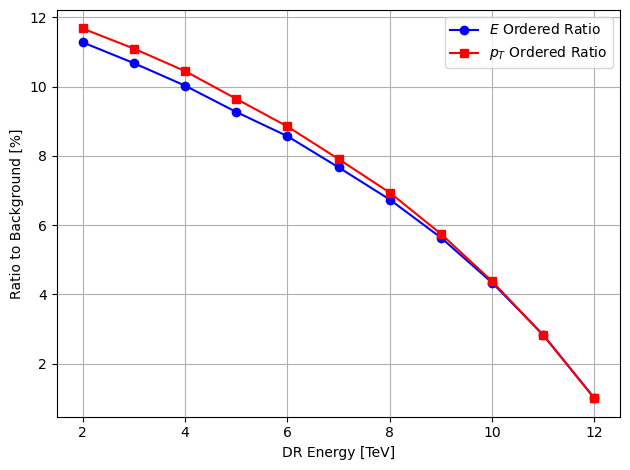

In [5]:
# Extract Mode 1 ratio data
lab_E_ratio_mode1 = ratios["lab_E"][1]
lab_pt_ratio_mode1 = ratios["lab_pt"][1]

# Plot both on the same graph
plt.figure()
plt.plot(x, lab_E_ratio_mode1, label= '$E$ Ordered Ratio', color='blue', marker='o')
plt.plot(x, lab_pt_ratio_mode1, label='$p_T$ Ordered Ratio', color='red', marker='s')

plt.xlabel('DR Energy [TeV]')
plt.ylabel('Ratio to Background [%]')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.title('Lab Frame - Mode 1 Ratio Comparison')
#plt.savefig('lab_mode1_ratio_comparison.png', dpi=300)  # Optional: Save the figure
plt.show()

Ratio of Ratios for Mode 1 (Energy Ordered / $p_T$ Ordered):
  DR 2: 0.97
  DR 3: 0.96
  DR 4: 0.96
  DR 5: 0.96
  DR 6: 0.97
  DR 7: 0.97
  DR 8: 0.97
  DR 9: 0.98
  DR 10: 0.99
  DR 11: 1.0
  DR 12: 1.0


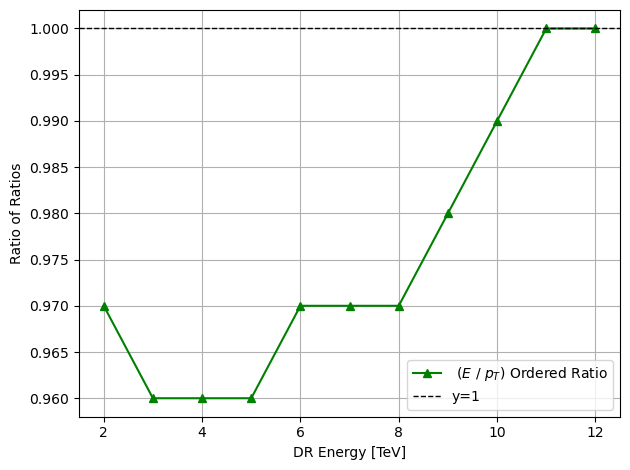

In [6]:
# Compute ratio of ratios for Mode 1
ratio_of_ratios_mode1 = [round(e / pt, 2) for e, pt in zip(lab_E_ratio_mode1, lab_pt_ratio_mode1)]

# Print the values
print("Ratio of Ratios for Mode 1 (Energy Ordered / $p_T$ Ordered):")
for dr_value, ratio in zip(x, ratio_of_ratios_mode1):
    print(f"  DR {dr_value}: {ratio}")

# Plot the ratio of ratios
plt.figure()
plt.plot(x, ratio_of_ratios_mode1, label=' ($E$ / $p_T$) Ordered Ratio', color='green', marker='^')

# Add horizontal line at y = 1
plt.axhline(y=1, color='black', linestyle='--', linewidth=1, label='y=1')

plt.xlabel('DR Energy [TeV]')
plt.ylabel('Ratio of Ratios')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.title('Ratio of Ratios: Lab Frame - Mode 1')
#plt.savefig('lab_mode1_ratio_of_ratios.png', dpi=300)  # Optional save
plt.show()